In [1]:
# ⬛ run this once per notebook
import pandas as pd, numpy as np, subprocess, psutil, time, os, math, re
from pathlib import Path
from urllib.parse import urlparse
from sklearn.metrics import confusion_matrix, classification_report

CSV_PATH = Path("val_urls.csv")          # your dataset
JS_CLI   = Path("score_url_cli.mjs")  

In [2]:
df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df):,} URLs")
df.head()

Loaded 7,999 URLs


,rec_id,url,label
0,36769,https://indianabeach.com/,0
1,65427,https://cr.mufg.coolstart.co/pc/MUFG_pcselectc...,1
2,17313,https://www.impacteventsinc.com/,0
3,11248,http://thinkenglish.me/definition/latency-stag...,0
4,78946,https://www.authorization-newrequest.link/Logi...,1


In [3]:
from tqdm.notebook import tqdm
import time, subprocess, re
import numpy as np

ANSI_RE = re.compile(r'\x1b\[[0-9;]*m')

def js_score(url: str) -> float:
    try:
        out = subprocess.check_output(
            ["node", str(JS_CLI), url],
            text=True, stderr=subprocess.DEVNULL
        )
        clean = ANSI_RE.sub("", out).strip()
        return float(clean)
    except Exception:
        return 0.0

# -----------------------------------------------------------------------------
scores = []
t0 = time.perf_counter()

for url in tqdm(df["url"], desc="Scoring URLs"):
    scores.append(js_score(url))

latency_ms = (time.perf_counter() - t0) / len(scores) * 1000
scores = np.array(scores, dtype=float)

print(f"Finished in {latency_ms:.2f} ms per URL (avg)")


Scoring URLs:   0%|          | 0/7999 [00:00<?, ?it/s]

Finished in 44.01 ms per URL (avg)


In [4]:
THR = 30
pred  = (scores >= THR).astype(int)
y_true = df["label"].to_numpy(int)

cm = confusion_matrix(y_true, pred, labels=[0,1])
tn, fp, fn, tp = cm.ravel()
tpr = tp/(tp+fn) if tp+fn else 0
fpr = fp/(fp+tn) if fp+tn else 0
prec = tp/(tp+fp) if tp+fp else 0
f1   = 2*prec*tpr/(prec+tpr+1e-9)

print("Confusion matrix [[TN FP][FN TP]]")
print(cm)
print(classification_report(y_true, pred, digits=3))
print(f"TPR  : {tpr:.3f}")
print(f"FPR  : {fpr:.3f}")
print(f"Prec : {prec:.3f}")
print(f"F1   : {f1:.3f}")
print(f"RAM  : {psutil.Process(os.getpid()).memory_info().rss/1024/1024:.1f} MB")


Confusion matrix [[TN FP][FN TP]]
[[4983   16]
 [2595  405]]
              precision    recall  f1-score   support

           0      0.658     0.997     0.792      4999
           1      0.962     0.135     0.237      3000

    accuracy                          0.674      7999
   macro avg      0.810     0.566     0.515      7999
weighted avg      0.772     0.674     0.584      7999

TPR  : 0.135
FPR  : 0.003
Prec : 0.962
F1   : 0.237
RAM  : 82.1 MB


In [16]:
import pandas as pd

# define your two masks
mask_low  = scores <= 0
mask_high = scores >= 31

def subset_metrics(mask, name):
    size = int(mask.sum())
    phish = int(((y_true == 1) & mask).sum())
    benign = size - phish
    return {
        "range": name,
        "count": size,
        "phish_rate (%)": round(phish/size*100, 1) if size else 0,
        "benign_rate (%)": round(benign/size*100, 1) if size else 0
    }

df_sub = pd.DataFrame([
    subset_metrics(mask_low,  "scores ≤ 5"),
    subset_metrics(mask_high, "scores ≥ 30")
])

df_sub


,range,count,phish_rate (%),benign_rate (%)
0,scores ≤ 5,3245,17.2,82.8
1,scores ≥ 30,675,92.6,7.4


In [ ]:
bins   = np.linspace(0, max(scores.max(),1), 11)
labels = [f"{int(b)}–{int(bins[1])}" for b in bins[:-1]]
bucket = pd.cut(scores, bins=bins, labels=labels, include_lowest=True)

tbl = (
    pd.DataFrame({"bucket":bucket,"truth":y_true,"pred":pred})
      .groupby("bucket", observed=True)
      .agg(total=('truth','size'),
           errors=(lambda d: (d.truth!=d.pred).sum()),
           FP =(lambda d: ((d.truth==0)&(d.pred==1)).sum()),
           FN =(lambda d: ((d.truth==1)&(d.pred==0)).sum()))
      .fillna(0).astype(int)
)
tbl["error_rate%"] = (tbl.errors / tbl.total * 100).round(1)
tbl["FP_rate%"]    = (tbl.FP     / tbl.total * 100).round(1)
tbl["FN_rate%"]    = (tbl.FN     / tbl.total * 100).round(1)

tbl


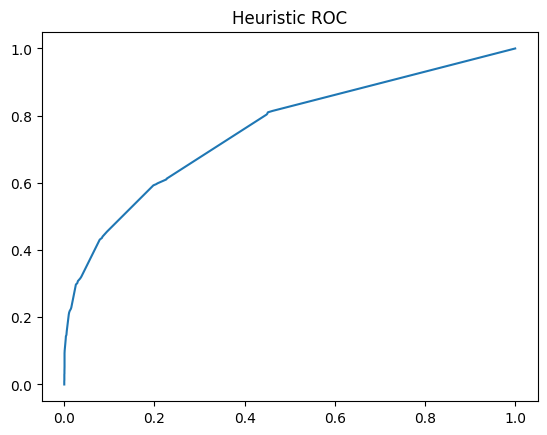

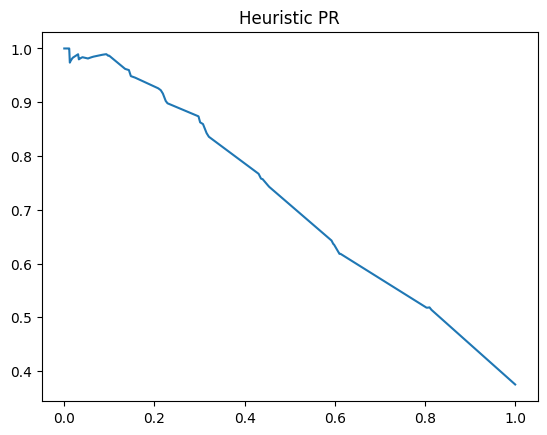

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_true, scores)
prec, reca, _ = precision_recall_curve(y_true, scores)

plt.figure(); plt.plot(fpr, tpr); plt.title("Heuristic ROC")
plt.figure(); plt.plot(reca, prec); plt.title("Heuristic PR")
plt.show()
